# Rental crisis in Portugal — H3: is the long-term rental crisis spreading out of Lisbon and Porto?

**Hypothesis H3:** since 2020, **long-term rental** prices grew **faster** in the municipalities **around** Lisbon and Porto (and in the rest of the country) than in the two cities themselves. People who can no longer pay the city rents move further out, and push rents up there.

| Data | Source | How we get it |
|---|---|---|
| Long-term rental price: median €/m² per month of new lease contracts (last 12 months), 1st quarter 2020 and latest quarter | INE – Statistics Portugal | **API** (same indicator as H2) |
| Resident population | INE – Statistics Portugal | **API** (same indicator as H2) |

No new data source: H3 re-uses the INE files that the H2 notebook already saved in `data/raw/`.

**The story in 4 charts**

1. Where is long-term rent highest – and how much did it change since 2020?
2. Where did long-term rent grow fastest: the cities, around them, or the rest of the country?
3. Around Lisbon and Porto: which municipalities had the biggest rises?
4. The whole country: the 10 fastest-growing municipalities.

**Three groups of municipalities**

| Group | Municipalities |
|---|---|
| **Lisbon & Porto** | the two cities (municipalities of Lisbon and Porto) |
| **Around Lisbon & Porto** | the other municipalities of the two metropolitan areas (e.g. Sintra, Almada, Barreiro, Gaia, Maia) |
| **Rest of Portugal** | all other municipalities in Portugal |

*Reminder: €/m² is the **monthly long-term rent per square metre** from signed contracts (INE), not a tourist price. Example: 10 €/m² × 80 m² flat ≈ 800 € per month.*

In [1]:
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

In [2]:
# Folders (this notebook lives in notebooks/, the data folder is one level up)
RAW_FOLDER = Path("data/raw")
CLEAN_FOLDER = Path("data/clean")
FIGURES_FOLDER = Path("figures")
for folder in [RAW_FOLDER, CLEAN_FOLDER, FIGURES_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

HEADERS = {"User-Agent": "data-wrangling-project (student project)"}   # tell the API who we are

**Chart style** – the same clean look as in the H2 notebook.

In [3]:
from matplotlib.colors import LinearSegmentedColormap

# Colours (tested for colour-blind readers)
ACCENT = "#1c5cab"        # dark blue  = main data / "more short-term rentals"
LIGHT_BLUE = "#86b6ef"    # light blue = comparison / "fewer short-term rentals"
INK = "#0b0b0b"           # main text
GREY_TEXT = "#52514e"     # subtitles
MUTED = "#898781"         # axis text and source notes
GRID = "#e1e0d9"          # thin gridlines
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])   # light -> dark for the heatmap

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.size": 11,
    "axes.edgecolor": GRID, "axes.labelcolor": GREY_TEXT,
    "xtick.color": GREY_TEXT, "ytick.color": MUTED, "xtick.labelsize": 11, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.fontsize": 10, "legend.labelcolor": GREY_TEXT,
})


def add_titles(fig, title, subtitle):
    """Bold headline that states the finding + grey subtitle that says what is measured."""
    fig.suptitle(title, x=0.02, y=0.98, ha="left", fontsize=15, fontweight="bold", color=INK)
    fig.text(0.02, 0.905, subtitle, ha="left", fontsize=11, color=GREY_TEXT)


def add_source(fig, text):
    """Small grey note at the bottom left (source, footnotes)."""
    fig.text(0.02, 0.015, text, ha="left", fontsize=8.5, color=MUTED)


def clean_bar_axes(ax):
    """Bar charts: values are written on the bars, so we hide the y axis and keep only the baseline."""
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="x", length=0, pad=8)
    ax.margins(y=0.15)


def euro_label(value_per_m2, flat_m2=80):
    """'9.75 €/m²' plus the monthly rent for an 80 m² flat, so the audience can picture it."""
    return f"{value_per_m2:.2f} €/m²\n≈ {value_per_m2 * flat_m2:,.0f} € / {flat_m2} m²"


def save_chart(fig, file_name):
    """Leave room for titles and source, save in high resolution for slides, then show."""
    fig.tight_layout(rect=(0, 0.05, 1, 0.87))
    fig.savefig(FIGURES_FOLDER / file_name, dpi=200)
    plt.show()

## Data collection — INE API

Same functions and same indicators as in H2. If the files already exist in `data/raw/` (because you ran the H2 notebook), they are read from disk and the API is **not** called again.

| Data | Indicator | Period |
|---|---|---|
| Long-term rental price (median €/m², last 12 months) | `0014696` | latest quarter and 1st quarter 2020 |
| Resident population | `0012918` | most recent year |

In [4]:
INE_URL = "https://www.ine.pt/ine/json_indicador/pindica.jsp"
RENT_INDICATOR = "0014696"
POPULATION_INDICATOR = "0012918"
RENT_START_PERIOD = "S5A20201"     # INE code for the 1st quarter of 2020 (first period available)


def get_json(url, params):
    """Call an API and return the JSON. Retries up to 3 times if the server is busy (HTTP 429)."""
    for attempt in range(1, 4):
        response = requests.get(url, params=params, headers=HEADERS, timeout=60)
        if response.status_code == 429:
            print(f"Too many requests – waiting {attempt * 5} seconds...")
            time.sleep(attempt * 5)
            continue
        response.raise_for_status()   # stops with an error for other problems (404, 500...)
        time.sleep(1)                 # be polite before the next request
        return response.json()
    raise Exception("The API is still busy after 3 attempts.")


def ine_json_to_table(ine_json):
    """INE returns {'Dados': {period: [records]}}. Turn it into one row per period and place."""
    rows = []
    for period, records in ine_json[0]["Dados"].items():
        for record in records:
            record["period"] = period
            rows.append(record)
    return pd.DataFrame(rows)


def load_ine(indicator, file_name, extra_params=None):
    """Read the saved file if it exists; otherwise call the INE API and save the result."""
    file_path = RAW_FOLDER / file_name
    if file_path.exists():
        print(f"Reading the saved file {file_name}")
        return pd.read_csv(file_path, dtype=str)
    print(f"Calling the INE API for indicator {indicator}")
    params = {"op": "2", "varcd": indicator, "lang": "PT", **(extra_params or {})}
    table = ine_json_to_table(get_json(INE_URL, params))
    table.to_csv(file_path, index=False)
    return table

In [5]:
rent_raw = load_ine(RENT_INDICATOR, "ine_rent_raw.csv")
rent_2020_raw = load_ine(RENT_INDICATOR, "ine_rent_2020_raw.csv", {"Dim1": RENT_START_PERIOD})
population_raw = load_ine(POPULATION_INDICATOR, "ine_population_raw.csv", {"Dim3": "T", "Dim4": "T"})  # T = total

Reading the saved file ine_rent_raw.csv
Reading the saved file ine_rent_2020_raw.csv
Reading the saved file ine_population_raw.csv


In [6]:
def quarter_label(period):
    """INE writes '2.º Trimestre de 2026'. Turn it into 'Q2 2026' for the charts."""
    found = re.search(r"(\d)\.º Trimestre de (\d{4})", period)
    return f"Q{found.group(1)} {found.group(2)}" if found else period


START_LABEL = quarter_label(rent_2020_raw["period"].iloc[0])
LATEST_LABEL = quarter_label(rent_raw["period"].iloc[0])
print("Long-term rent from", START_LABEL, "to", LATEST_LABEL)

Long-term rent from Q1 2020 to Q2 2026


## Checking the data

We already explored these files in H2. The one new thing we need is **where** each municipality is. INE's `geocod` tells us:

| Part of `geocod` | Meaning | Example |
|---|---|---|
| characters 1–3 | region (NUTS III) | `11A` = Porto Metropolitan Area, `1A0` = Greater Lisbon, `1B0` = Península de Setúbal |
| last 4 characters | municipality code | `1106` = Lisbon, `1312` = Porto |

Greater Lisbon + Península de Setúbal together form the **Lisbon Metropolitan Area**.

In [7]:
municipalities = rent_raw[rent_raw["geocod"].str.len() == 7]
municipalities["geocod"].str[:3].value_counts().head(10)       # how many municipalities per region

geocod
11D    19
200    19
192    19
11A    17
150    16
196    15
1C3    15
1C4    14
194    14
1C2    13
Name: count, dtype: int64

**Cleaning plan**

| Problem | Technique |
|---|---|
| INE mixes country, regions, municipalities and parishes | filter rows (municipalities of Portugal) |
| Values stored as text | convert types |
| Municipality code and region hidden inside `geocod` | string slicing (`.str[:3]`, `.str[-4:]`) |
| Municipalities without a long-term rent value in 2020 or now (too few contracts) | drop missing values (and report them) |
| Region code → readable group name | mapping with a function (`.map`) |

## Cleaning

In [8]:
CITY_CODES = ["1106", "1312"]                  # Lisbon, Porto
METRO_REGIONS = ["11A", "1A0", "1B0"]          # Porto metro area, Greater Lisbon, Península de Setúbal
GROUP_ORDER = ["Lisbon & Porto", "Around Lisbon & Porto", "Rest of Portugal"]


def keep_portugal_municipalities(df):
    """Municipalities have a 7-character geocod starting with '1' (Azores and Madeira are not included)."""
    return df[(df["geocod"].str.len() == 7) & (df["geocod"].str.startswith("1"))].copy()


def clean_ine(df, value_name):
    """Main cleaning function for an INE table: one row per municipality."""
    df = keep_portugal_municipalities(df)
    if "dim_3" in df.columns:                                     # population: keep totals only
        df = df[(df["dim_3"] == "T") & (df["dim_4"] == "T")]
    df[value_name] = pd.to_numeric(df["valor"], errors="coerce")  # text -> number
    df["municipality_code"] = df["geocod"].str[-4:]               # last 4 digits = municipality
    df["region_code"] = df["geocod"].str[:3]                      # first 3 characters = NUTS III region
    df = df.rename(columns={"geodsg": "municipality"})
    df["municipality"] = df["municipality"].replace({"Lisboa": "Lisbon"})   # English name in tables and charts
    return df[["municipality_code", "region_code", "municipality", value_name]]


def location_group(row):
    """Put each municipality in one of the three groups."""
    if row["municipality_code"] in CITY_CODES:
        return "Lisbon & Porto"
    if row["region_code"] in METRO_REGIONS:
        return "Around Lisbon & Porto"
    return "Rest of Portugal"


rent = clean_ine(rent_raw, "long_term_rent")
rent_2020 = clean_ine(rent_2020_raw, "long_term_rent_2020")
population = clean_ine(population_raw, "population")
print("Municipalities with a long-term rent value now:", rent["long_term_rent"].notna().sum(), "of", len(rent))

Municipalities with a long-term rent value now: 237 of 278


## Combining the data

One row per municipality: long-term rent in 2020 and now, population, group and growth.

In [9]:
h3 = rent.merge(rent_2020[["municipality_code", "long_term_rent_2020"]], on="municipality_code", how="left")
h3 = h3.merge(population[["municipality_code", "population"]], on="municipality_code", how="left")

missing = h3["long_term_rent"].isna() | h3["long_term_rent_2020"].isna()
print(f"{missing.sum()} of {len(h3)} municipalities have no long-term rent value in {START_LABEL} or {LATEST_LABEL} "
      f"(too few contracts) -> removed")
h3 = h3[~missing].copy()

h3["group"] = pd.Categorical(h3.apply(location_group, axis=1), categories=GROUP_ORDER, ordered=True)
h3["rent_growth_pct"] = (h3["long_term_rent"] / h3["long_term_rent_2020"] - 1) * 100

h3.to_csv(CLEAN_FOLDER / "h3_clean.csv", index=False)
h3["group"].value_counts().reindex(GROUP_ORDER)

64 of 278 municipalities have no long-term rent value in Q1 2020 or Q2 2026 (too few contracts) -> removed


group
Lisbon & Porto             2
Around Lisbon & Porto     33
Rest of Portugal         179
Name: count, dtype: int64

## Analysis

**Summary table** – median of the municipalities in each group (each municipality counts once).

In [10]:
summary = h3.groupby("group", observed=True).agg(
    municipalities=("municipality", "size"),
    rent_2020=("long_term_rent_2020", "median"),
    rent_now=("long_term_rent", "median"),
    growth_pct=("rent_growth_pct", "median"),
)
summary.round(2)

,municipalities,rent_2020,rent_now,growth_pct
group,,,,
Lisbon & Porto,2,10.58,15.96,51.79
Around Lisbon & Porto,33,5.89,10.19,72.99
Rest of Portugal,179,3.30,5.70,70.91


In [11]:
# The two cities one by one (the group "Lisbon & Porto" has only these two)
h3[h3["group"] == "Lisbon & Porto"][["municipality", "long_term_rent_2020", "long_term_rent", "rent_growth_pct"]].round(1)

,municipality,long_term_rent_2020,long_term_rent,rent_growth_pct
232,Porto,9.1,14.5,59.3
236,Lisbon,12.1,17.4,44.3


### Chart 1 – Long-term rent in 2020 and now, by group

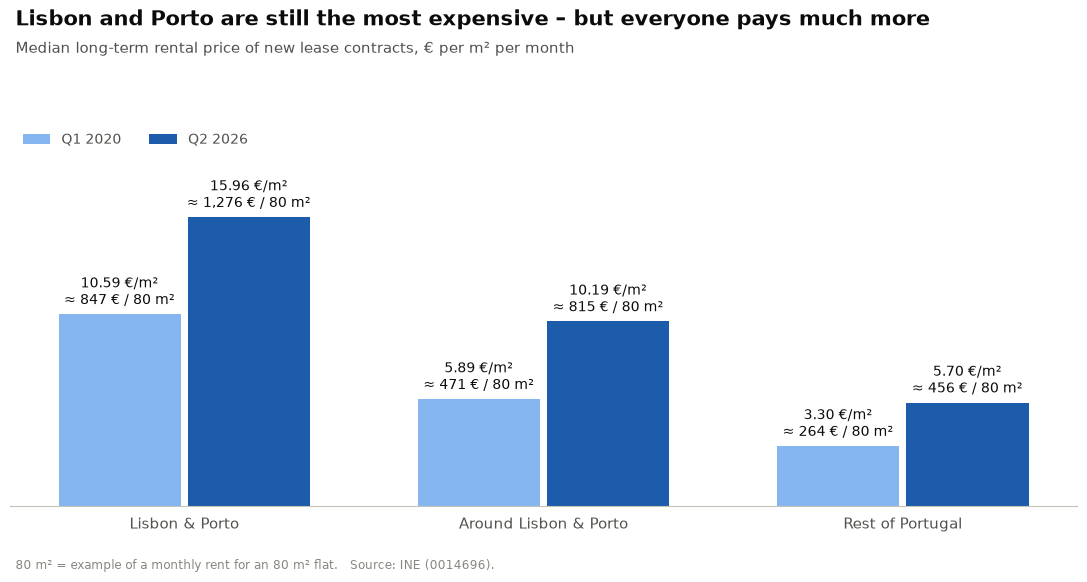

In [12]:
x = np.arange(len(summary))
fig, ax = plt.subplots(figsize=(11, 5.8))
for offset, column, color, name in [(-0.18, "rent_2020", LIGHT_BLUE, START_LABEL),
                                    (0.18, "rent_now", ACCENT, LATEST_LABEL)]:
    bars = ax.bar(x + offset, summary[column], width=0.34, color=color, label=name)
    ax.bar_label(bars, labels=[euro_label(v) for v in summary[column]], padding=4, fontsize=10, color=INK)
ax.set_xticks(x, summary.index)
clean_bar_axes(ax)
ax.legend(loc="lower left", frameon=False, ncol=2, bbox_to_anchor=(0, 1.0))
ax.margins(y=0.2)
add_titles(fig, "Lisbon and Porto are still the most expensive – but everyone pays much more",
           "Median long-term rental price of new lease contracts, € per m² per month")
add_source(fig, "80 m² = example of a monthly rent for an 80 m² flat.   Source: INE (0014696).")
save_chart(fig, "h3_1_long_term_rent_by_group.png")

### Chart 2 – Where did long-term rent grow fastest?

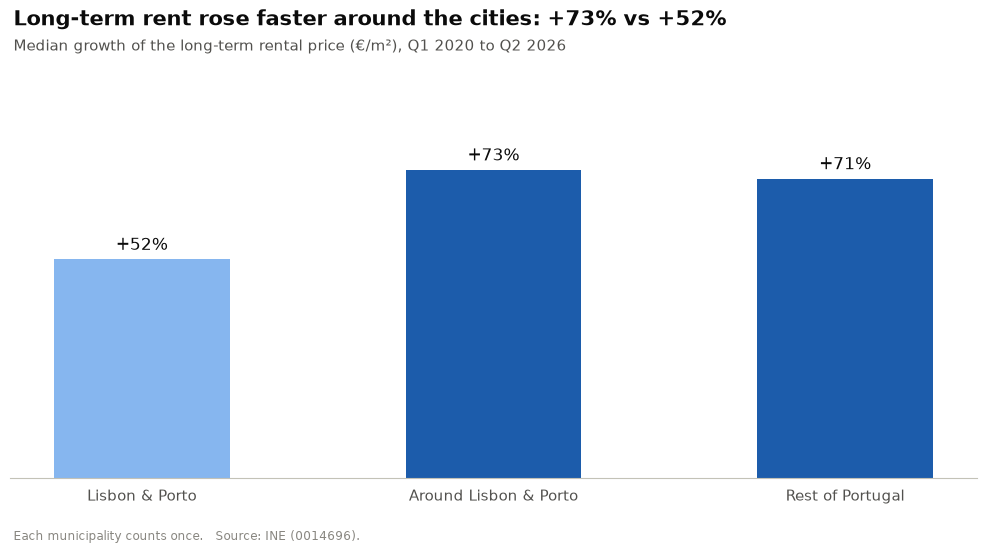

In [13]:
city_growth = summary.loc["Lisbon & Porto", "growth_pct"]
around_growth = summary.loc["Around Lisbon & Porto", "growth_pct"]
faster_outside = around_growth > city_growth

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(summary.index, summary["growth_pct"], width=0.5,
              color=[LIGHT_BLUE if group == "Lisbon & Porto" else ACCENT for group in summary.index])
ax.bar_label(bars, labels=[f"+{v:.0f}%" for v in summary["growth_pct"]], padding=4, fontsize=12, color=INK)
clean_bar_axes(ax)
title = (f"Long-term rent rose faster around the cities: +{around_growth:.0f}% vs +{city_growth:.0f}%"
         if faster_outside else
         f"Long-term rent grew fastest in Lisbon and Porto (+{city_growth:.0f}%)")
add_titles(fig, title, f"Median growth of the long-term rental price (€/m²), {START_LABEL} to {LATEST_LABEL}")
add_source(fig, "Each municipality counts once.   Source: INE (0014696).")
save_chart(fig, "h3_2_long_term_rent_growth_by_group.png")

**The gap is closing.** How much more expensive are the cities than the municipalities around them?

In [14]:
gap_2020 = summary.loc["Lisbon & Porto", "rent_2020"] / summary.loc["Around Lisbon & Porto", "rent_2020"]
gap_now = summary.loc["Lisbon & Porto", "rent_now"] / summary.loc["Around Lisbon & Porto", "rent_now"]
print(f"{START_LABEL}: the cities were {(gap_2020 - 1) * 100:.0f}% more expensive than the municipalities around them")
print(f"{LATEST_LABEL}: the cities are  {(gap_now - 1) * 100:.0f}% more expensive than the municipalities around them")

Q1 2020: the cities were 80% more expensive than the municipalities around them
Q2 2026: the cities are  57% more expensive than the municipalities around them


### Chart 3 – Around Lisbon and Porto: the biggest rises

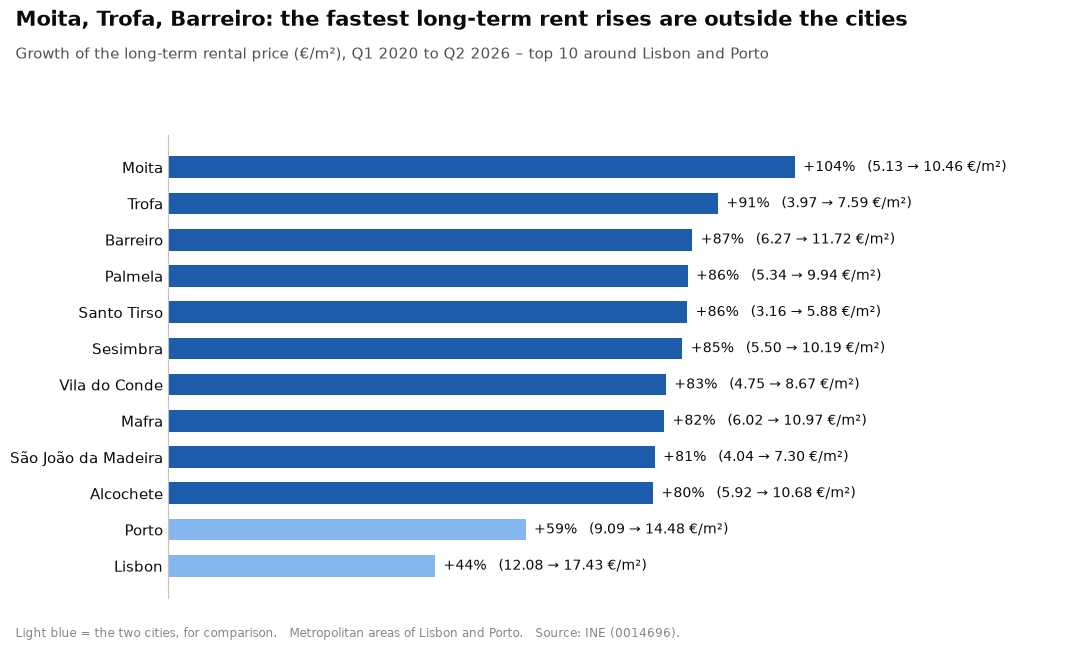

In [15]:
def horizontal_bar_chart(table, colors, title, subtitle, source, file_name):
    """Horizontal bars (largest on top) with the growth % and the €/m² change written next to each bar."""
    table = table.iloc[::-1]                                  # matplotlib draws from the bottom up
    fig, ax = plt.subplots(figsize=(11, 6.5))
    bars = ax.barh(table["municipality"], table["rent_growth_pct"], color=colors[::-1], height=0.6)
    labels = [f"+{row.rent_growth_pct:.0f}%   ({row.long_term_rent_2020:.2f} → {row.long_term_rent:.2f} €/m²)"
              for row in table.itertuples()]
    ax.bar_label(bars, labels=labels, padding=6, fontsize=10, color=INK)
    ax.xaxis.set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.tick_params(axis="y", length=0, labelsize=11, labelcolor=INK)
    ax.margins(x=0.45)
    add_titles(fig, title, subtitle)
    add_source(fig, source)
    save_chart(fig, file_name)


metro = h3[h3["group"] != "Rest of Portugal"].sort_values("rent_growth_pct", ascending=False)
top_metro = pd.concat([metro[metro["group"] == "Around Lisbon & Porto"].head(10),
                       metro[metro["group"] == "Lisbon & Porto"]])            # top 10 + the two cities for comparison
colors = [LIGHT_BLUE if group == "Lisbon & Porto" else ACCENT for group in top_metro["group"]]
top_names = ", ".join(top_metro["municipality"].head(3))

horizontal_bar_chart(
    top_metro, colors,
    f"{top_names}: the fastest long-term rent rises are outside the cities",
    f"Growth of the long-term rental price (€/m²), {START_LABEL} to {LATEST_LABEL} – top 10 around Lisbon and Porto",
    "Light blue = the two cities, for comparison.   Metropolitan areas of Lisbon and Porto.   Source: INE (0014696).",
    "h3_3_top10_around_cities.png")

### Chart 4 – The whole country: the 10 fastest-growing municipalities

Very small municipalities have few contracts, so their price can jump a lot by chance. To keep the chart reliable, we only show municipalities with **at least 20,000 residents**.

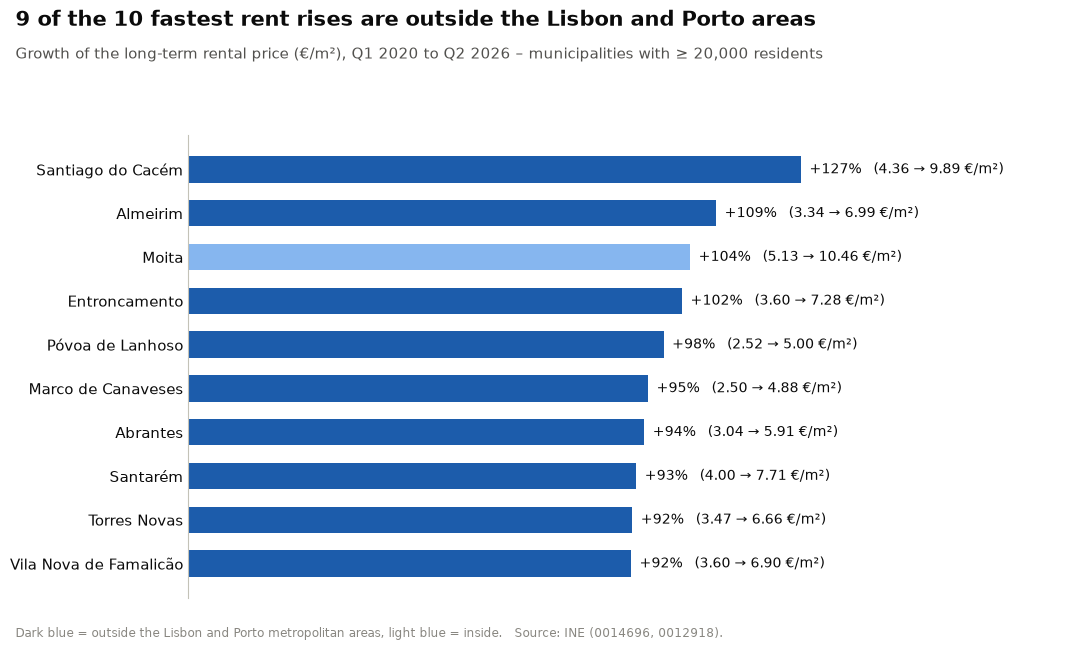

In [16]:
MIN_POPULATION = 20_000

top_country = (h3[h3["population"] >= MIN_POPULATION]
               .sort_values("rent_growth_pct", ascending=False)
               .head(10))
colors = [ACCENT if group == "Rest of Portugal" else LIGHT_BLUE for group in top_country["group"]]
outside_metro = (top_country["group"] == "Rest of Portugal").sum()

horizontal_bar_chart(
    top_country, colors,
    f"{outside_metro} of the 10 fastest rent rises are outside the Lisbon and Porto areas",
    f"Growth of the long-term rental price (€/m²), {START_LABEL} to {LATEST_LABEL} – municipalities with "
    f"≥ {MIN_POPULATION:,} residents",
    "Dark blue = outside the Lisbon and Porto metropolitan areas, light blue = inside.   Source: INE (0014696, 0012918).",
    "h3_4_top10_country.png")

## Conclusions

*Numbers from our test run on 29 September 2026 (long-term rent 1st quarter 2020 vs 2nd quarter 2026). **Check them against the tables above after you run the notebook**, because the 2020 file you download may include a few more municipalities.*

**1. The cities are still the most expensive (Chart 1).** Median long-term rent in Lisbon & Porto went from ≈ 10.6 to ≈ 16.0 €/m² (≈ 1,275 € per month for 80 m²). Around them: ≈ 5.9 → 10.2 €/m² (≈ 815 €). Rest of Portugal: ≈ 3.3 → 5.7 €/m² (≈ 460 €).

**2. But long-term rent grew faster outside the cities (Chart 2).** Since 2020: Lisbon & Porto **≈ +52%** (Lisbon +44%, Porto +59%), around them **≈ +73%**, rest of Portugal **≈ +71%**.

**3. The gap is closing.** In 2020 the cities were ≈ 80% more expensive than the municipalities around them; now ≈ 57%.

**4. The biggest rises are in the outer ring (Chart 3).** Moita (≈ +104%), Trofa, Barreiro, Palmela, Santo Tirso and Sesimbra grew much faster than Lisbon, Cascais or Oeiras (≈ +44–56%).

**5. It is a national problem (Chart 4).** Most of the 10 fastest-growing municipalities with ≥ 20,000 residents are **outside** the two metropolitan areas (e.g. Santiago do Cacém, Almeirim, Entroncamento, Santarém).

### Answer to H3
**Supported.** The long-term rental crisis is no longer only a Lisbon and Porto problem: prices in the cities are still the highest, but they rose **faster around the cities and in the rest of the country**, and the gap between the cities and their surroundings is getting smaller.

**Link with H1 and H2:** cheaper places are catching up – and wages outside the big cities are usually lower (H1), so the pressure on families there may be even bigger.

**Correlation is not causation:** our data show *where* rents grew, not *why*. People moving out of the cities is one likely reason; others are remote work, new jobs (e.g. Sines), tourism and few new homes.

**Limitations**
* Azores and Madeira are not included (INE codes for the islands start with 2 and 3).
* Growth in % is larger when the starting price is low (5 → 10 €/m² is +100%, 12 → 17 €/m² is +42%). That is why we also show the €/m² values.
* Municipalities with too few contracts in 2020 or now have no INE value and are not included.
* The "Lisbon & Porto" group has only 2 municipalities; each municipality counts once in the medians.
* INE values are signed contracts (lower than advertised prices) and a 12-month median.